In [1]:
import matplotlib.pyplot as plt # type: ignore
import numpy as np # type: ignore
import xarray as xr # type: ignore

xr.set_options(keep_attrs=True, display_expand_data=False)
np.set_printoptions(threshold=10, edgeitems=2)

%xmode minimal
%matplotlib inline
%config InlineBackend.figure_format='retina'

Exception reporting mode: Minimal


In [2]:
Path = "../dataset/era5_temp.nc"
ds = xr.open_dataset(Path)

In [3]:
ds

<xarray.Dataset> Size: 36GB
Dimensions:     (valid_time: 8760, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 140kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 36GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T10:57 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 8760, 'latitude': 721, 'longitude': 1440})

In [5]:
ds['valid_time'].values

array(['2025-01-01T00:00:00.000000000', '2025-01-01T01:00:00.000000000',
       ..., '2025-12-31T22:00:00.000000000',
       '2025-12-31T23:00:00.000000000'], dtype='datetime64[ns]')

In [6]:
ds['valid_time'].values.shape

(8760,)

In [7]:
ds.latitude.values[:5]

array([90.  , 89.75, 89.5 , 89.25, 89.  ])

In [8]:
ds.latitude.values[-5:]

array([-89.  , -89.25, -89.5 , -89.75, -90.  ])

In [9]:
ds['t2m']


<xarray.DataArray 't2m' (valid_time: 8760, latitude: 721, longitude: 1440)> Size: 36GB
[9094982400 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 140kB ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [10]:
ds.coords

Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 140kB ...

In [11]:
ds.latitude #da.coords["latitude"]

<xarray.DataArray 'latitude' (latitude: 721)> Size: 6kB
90.0 89.75 89.5 89.25 89.0 88.75 88.5 ... -88.75 -89.0 -89.25 -89.5 -89.75 -90.0
Coordinates:
    number    int64 8B ...
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

In [12]:
ds.attrs

{'GRIB_centre': 'ecmf',
 'GRIB_centreDescription': 'European Centre for Medium-Range Weather Forecasts',
 'GRIB_subCentre': np.int64(0),
 'Conventions': 'CF-1.7',
 'institution': 'European Centre for Medium-Range Weather Forecasts',
 'history': '2026-01-06T10:57 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmp6uw6kis5/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["instant"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}'}

In [13]:
ds.data_vars

Data variables:
    t2m      (valid_time, latitude, longitude) float32 36GB ...

- label based indexing: sel (selection) - inderited froma pandas library
- index based indexing: isel (index selection)

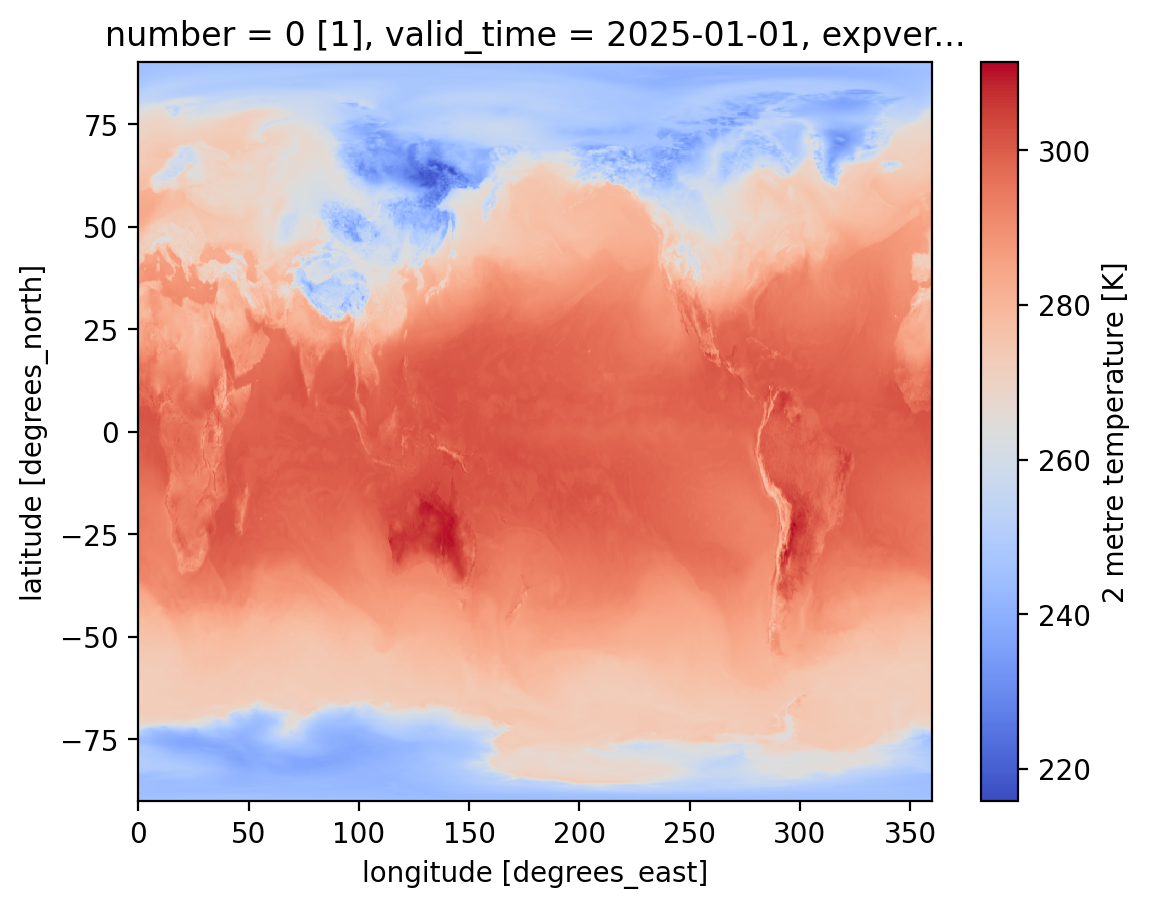

In [14]:
ds.t2m.isel(valid_time=0).plot(x="longitude", y="latitude", cmap="coolwarm");

In [25]:
broadcasted_dim = ds.latitude * ds.longitude
broadcasted_dim.shape
broadcasted_dim[:,:]

<xarray.DataArray (latitude: 721, longitude: 1440)> Size: 8MB
0.0 22.5 45.0 67.5 90.0 ... -3.231e+04 -3.233e+04 -3.236e+04 -3.238e+04
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing

In [26]:
ds.t2m

<xarray.DataArray 't2m' (valid_time: 8760, latitude: 721, longitude: 1440)> Size: 36GB
[9094982400 values with dtype=float32]
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 140kB ...
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [28]:
ds.groupby('valid_time.season')

DatasetGroupBy, grouped over 'season'
4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'.

In [30]:
ds.groupby('valid_time.dayofyear')

DatasetGroupBy, grouped over 'dayofyear'
365 groups with labels 1, 2, 3, 4, 5, ..., 362, 363, 364, 365.